# Laboratorio 5.1: Regresion Lineal con PyTorch (Univariable)

**Basado en:** Lab_1.ipynb
**Dataset:** ATP Matches till 2022

# Secciones PyTorch obligatorias (nn, datasets, save)

Estas secciones deben estar presentes en cada Lab_5.x.

## Modelos secuenciales

Definimos redes con `nn.Sequential`.

In [2]:
import torch
from torch import nn

modelo_secuencial = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)
print(modelo_secuencial)

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)


## Optimizadores y Funciones de perdida

Ejemplo de un paso de entrenamiento.

In [3]:
x_demo = torch.randn(16, 4)
y_demo = torch.randn(16, 1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(modelo_secuencial.parameters(), lr=0.01)

pred = modelo_secuencial(x_demo)
loss = loss_fn(pred, y_demo)
optimizer.zero_grad()
loss.backward()
optimizer.step()
print(f'Loss demo: {loss.item():.4f}')

Loss demo: 1.3612


## Modelos custom

Se define una clase que hereda de `nn.Module`.

In [4]:
class ModeloCustom(nn.Module):
    def __init__(self, in_features, hidden):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.act(self.fc1(x))
        return self.fc2(x)

modelo_custom = ModeloCustom(4, 8)
print(modelo_custom)

ModeloCustom(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


## Accediendo a las capas

Inspeccion de pesos y bias.

In [5]:
print('Pesos fc1:', modelo_custom.fc1.weight.shape)
print('Bias fc1:', modelo_custom.fc1.bias.shape)

Pesos fc1: torch.Size([8, 4])
Bias fc1: torch.Size([8])


## Iterando tensores

In [6]:
X_tensor = torch.randn(5, 3)
for i in range(len(X_tensor)):
    _ = X_tensor[i]

## Iterando por Batches

In [7]:
batch_size = 2
for i in range(0, len(X_tensor), batch_size):
    batch = X_tensor[i:i+batch_size]

## La clase Dataset

In [8]:
from torch.utils.data import Dataset, DataLoader

class DemoDataset(Dataset):
    def __init__(self, X):
        self.X = X
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

demo_ds = DemoDataset(X_tensor)
print('Len dataset:', len(demo_ds))

Len dataset: 5


## La clase DataLoader

In [9]:
demo_loader = DataLoader(demo_ds, batch_size=2, shuffle=True)
for batch in demo_loader:
    _ = batch

## Guardando modelos

Guardado del `state_dict`.

In [10]:
import os
save_dir = 'Lab/tmp_pytorch'
os.makedirs(save_dir, exist_ok=True)
torch.save(modelo_custom.state_dict(), os.path.join(save_dir, 'modelo_custom.pth'))

### Guardando los parametros

In [11]:
modelo_cargado = ModeloCustom(4, 8)
modelo_cargado.load_state_dict(torch.load(os.path.join(save_dir, 'modelo_custom.pth')))
modelo_cargado.eval()

ModeloCustom(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)

## Exportando modelos

### Torchscript

In [12]:
example_input = torch.randn(1, 4)
scripted = torch.jit.trace(modelo_custom, example_input)
scripted.save(os.path.join(save_dir, 'modelo_custom_scripted.pt'))

### ONNX

In [13]:
# Si onnx no esta instalado, comentar esta celda
# import torch.onnx
# torch.onnx.export(modelo_custom, example_input, os.path.join(save_dir, 'modelo_custom.onnx'),
#                   input_names=['input'], output_names=['output'], opset_version=11)

## Fase 1: Entender el dataset

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('../Datasets/1_ATP_matches_D/atp_matches_till_2022.csv')
feature_col = 'w_svpt'
target_col = 'minutes'
df = df[[feature_col, target_col]].dropna()
X = df[[feature_col]].values.astype(np.float32)
y = df[[target_col]].values.astype(np.float32)
print('Filas:', X.shape[0])

Filas: 89455


## Fase 2: Utilizacion y entrenamiento

Epoch 10/50 | Loss: 0.1902
Epoch 20/50 | Loss: 0.1902
Epoch 30/50 | Loss: 0.1902
Epoch 40/50 | Loss: 0.1902
Epoch 50/50 | Loss: 0.1902


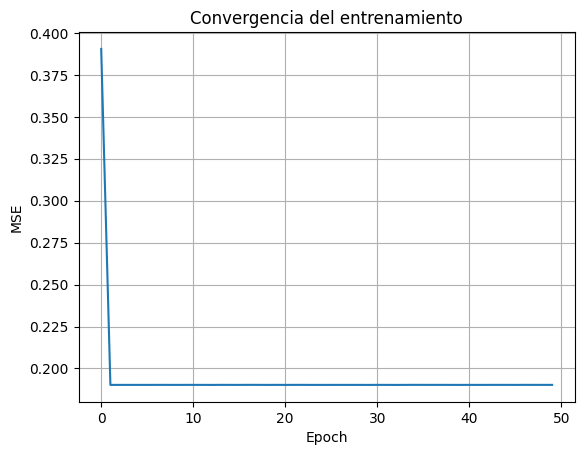

In [15]:
# Normalizacion
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
y_mean = y.mean(axis=0)
y_std = y.std(axis=0)
X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

# Dataset y DataLoader
X_t = torch.tensor(X_norm, dtype=torch.float32)
y_t = torch.tensor(y_norm, dtype=torch.float32)
dataset = torch.utils.data.TensorDataset(X_t, y_t)
loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=True)

# Modelo
model = nn.Linear(1, 1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Entrenamiento
epochs = 50
loss_history = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(loader.dataset)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f}')

# Grafico de perdida
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Convergencia del entrenamiento')
plt.grid(True)
plt.show()

## Fase 3: Pruebas

In [17]:
model.eval()
# Prediccion para un ejemplo promedio
x_sample = np.array([[X.mean()]], dtype=np.float32)
x_sample_norm = (x_sample - X_mean) / X_std
with torch.no_grad():
    y_pred_norm = model(torch.tensor(x_sample_norm))
y_pred = y_pred_norm.numpy() * y_std + y_mean
print(f'Prediccion de minutos (promedio): {float(y_pred.item()):.2f}')
print(f'Duracion real promedio: {float(y.mean()):.2f}')


Prediccion de minutos (promedio): 103.53
Duracion real promedio: 103.53
